# Flow-corrected posterior with multiple pulsars (using CURN)

In [1]:
from flow_helpers import *

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True
)

In [ ]:
npsr = 2
psrs = allpsrs[:npsr]
Tspan = ds.getspan(psrs)

In [ ]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw

# here we fix the RN and WN, which should make the result exact
rn_init_params = [{'log10_A': -13.0, 'gamma': 6.5}]*npsr # broad prior
ecorr = False 
fixed_wn = True

pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= rn_init_params, ecorr = ecorr, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn)



In [ ]:
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]

In [ ]:
# computing _0 quantities
Ls, ahat0_list = [], []
logdet_sigma0_inv = 0.0

for psr_model in pslmodels:
    ahat0, cf_inv = psr_model.conditional({})
            
    sigma0_inv_psr = cf_inv[0] @ cf_inv[0].T
    logdet_sigma0_inv += 2.0 * jnp.sum(jnp.log(jnp.diag(cf_inv[0])))
            
    sigma0_psr = jsp.linalg.cho_solve((cf_inv[0], True), jnp.eye(cf_inv[0].shape[0]))
    L_sigma0 = jsp.linalg.cholesky(sigma0_psr, lower=True)
            
    Ls.append(L_sigma0)
    ahat0_list.append(ahat0)
            

In [9]:
num_samples = 512 # num of samples used in flow
num_params  = 2*rn_components # num of params to fit flow to (in this case, 60 RN coefficient / psr)
rng = jax.random.key(0)

trained_flows, train_keys = fit_flows(pslmodels, logxs, ahat0_list, Ls, 
                                               num_samples, num_params, rng)

Fitting flow for pulsar J1713+0747


 21%|██▏       | 213/1001 [01:54<07:02,  1.87it/s, loss=-803187.77]

Early stopping at iteration 213
Fitting flow for pulsar J1909-3744



 19%|█▉        | 194/1001 [01:40<06:56,  1.94it/s, loss=-468624.37]

Early stopping at iteration 194


In [10]:
# computing _f quantities
num_flow_samples = 100000 # rather large to get good estimate of ahat_f and Sigma_f from samples
ahat_f, Sigma_f, L_f = gauss_approx_flow_mpsrs(trained_flows, train_keys, ahat0_list, 
                                                Ls, num_flow_samples=num_flow_samples)

# precomputing quantities needed in likelihood model
Sigma_f_inv, logdet_arr, b_flow, quad_f = eval_flow_quantity_mpsrs(ahat_f, Sigma_f, L_f)

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

# extracting TtNT for all psrs
TNT_flow, logdet_phi0 = TtNT_mpsrs(Sigma_f_inv, params_list=[rn_init_params[0]] * npsr,
                                f=f, df=df, powerlaw=powerlaw)

log_const = 0.5 * logdet_phi0


In [11]:
psrnames = [psr.name for psr in pslmodels]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)

In [14]:
crn_gamma_key = "crn_gamma"
crn_log10A_key = "crn_log10_A"
crn_components = 14

commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, rn_components, T=Tspan, name='red_noise')
commongp_crn =ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])
getN_common = commongp.Phi.getN 
getN_crn = commongp_crn.Phi.getN

In [15]:
phi_crn_args = (crn_components, rn_amp_keys, rn_gamma_keys, crn_log10A_key, 
        crn_gamma_key, getN_common, getN_crn)

phi_crn_partial = jax.jit(lambda rho: phi_crn(rho, *phi_crn_args))

In [18]:
logL_flow_list = [flow.log_prob for flow in trained_flows]
base_model_args = (b_flow, phi_crn_partial, log_const, TNT_flow, npsr, rn_components,
                   rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key)

flow_model = make_model_crn_flow( *base_model_args, logL_flow_list=logL_flow_list,
    ahat_0=jnp.stack(ahat0_list), L_0=jnp.stack(Ls), ahat_f=ahat_f, L_sigma_f=L_f,)

init_params = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0, crn_gamma_key: 4.0,
      "xi": jnp.zeros((npsr, 2 * rn_components))}

kernel_flow  = infer.NUTS(flow_model)
sampler_flow = infer.MCMC(kernel_flow, num_warmup=1000, num_samples=2000)
sampler_flow.run(jax.random.PRNGKey(2), init_params = init_params)
samples_flow = sampler_flow.get_samples()
sampler_flow.print_summary()

sample: 100%|██████████| 3000/3000 [15:48<00:00,  3.16it/s, 319 steps of size 6.69e-02. acc. prob=0.52] 



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1713+0747_red_noise_gamma      1.41      0.48      1.45      0.58      2.20    244.41      1.00
  J1713+0747_red_noise_log10_A    -13.60      0.07    -13.60    -13.70    -13.49    581.15      1.01
    J1909-3744_red_noise_gamma      0.95      0.71      0.76      0.00      1.89    173.56      1.01
  J1909-3744_red_noise_log10_A    -13.72      0.08    -13.72    -13.84    -13.59    248.91      1.00
                     crn_gamma      3.73      1.43      3.72      1.66      6.68   1135.02      1.00
                   crn_log10_A    -15.52      1.65    -14.78    -18.61    -13.81    237.62      1.01
                       xi[0,0]     -0.02      1.02     -0.06     -1.72      1.56    403.81      1.00
                       xi[0,1]      0.08      1.01      0.09     -1.57      1.70    345.64      1.01
                       xi[0,2]     -0.10      0.98     -0.14     -1.61      1.53    479.78

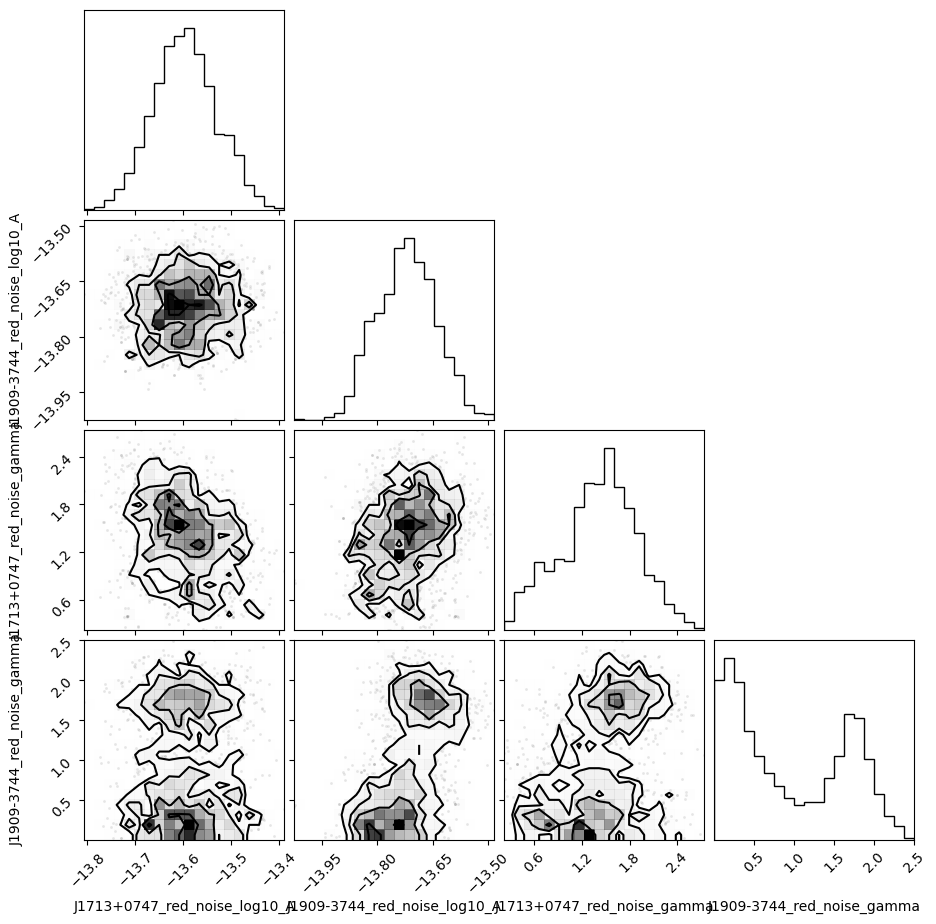

In [19]:
irn_samples_flow = {k: samples_flow[k] for k in rn_amp_keys + rn_gamma_keys}
corner.corner(irn_samples_flow)
plt.show()

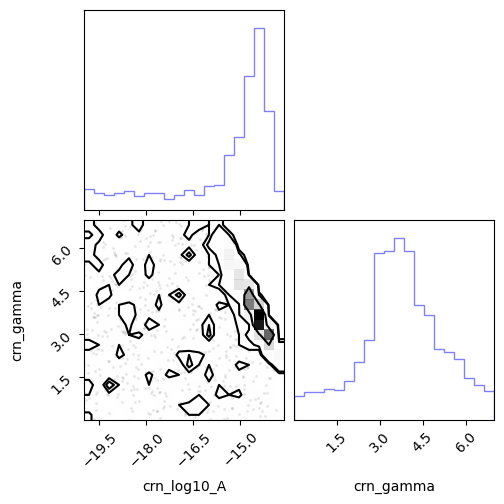

In [20]:
crn_samples_flow = {k: samples_flow[k] for k in [crn_log10A_key, crn_gamma_key]}
corner.corner(crn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"})
plt.show()